<a href="https://colab.research.google.com/github/OscarGiordano/UPSRJ-REDES-NEURONALES/blob/develop/DNN_LINEAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#""red densa con keras para prediccion linear""
##objetivo
implementar una red neuronal completamente conectada (DNN) simple usando keras, para predecir la dureza del concreto a partir de componentes quimicos.

#""cargar y preparar los datos""
##objetivo
usaremos el datashet

In [ ]:
import pandas as pd
#url del datshet a usar
url="https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
data = pd.read_excel(url)
data.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


necesitamos ahora separar los predictores y la variable objetivo de nuestra base de datos para ello seleccionaremos la columna  (mpa, megapascals) como selector y el resto como nuestros predictores

In [ ]:
#columna de strengh
strenght_column= "Concrete compressive strength(MPa, megapascals) "

In [ ]:
# separar predictores
predictors = data.drop(columns=["Concrete compressive strength(MPa, megapascals) "])
predictors.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day)
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360


In [ ]:
# Separar selector
selector = data["Concrete compressive strength(MPa, megapascals) "]
selector.head()

,"Concrete compressive strength(MPa, megapascals)"
0,79.986111
1,61.887366
2,40.269535
3,41.052780
4,44.296075


In [ ]:
print(data.columns)
predictors = data.drop(columns=["Concrete compressive strength(MPa, megapascals) "])
predictors.head()
# separar selctor
selector = data["Concrete compressive strength(MPa, megapascals) "]
selector.head()

Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) '],
      dtype='object')


,"Concrete compressive strength(MPa, megapascals)"
0,79.986111
1,61.887366
2,40.269535
3,41.052780
4,44.296075


2. "definir nuestro modelo "
ncesitamos generar un modelo secuencial con una red neuronal densa (DNN) con una capa de entrada, una capa oculta y una capa de salida
la capa de salida contendra solo una neurona sobre la cual va a divergir todo el contenido de la capa previa.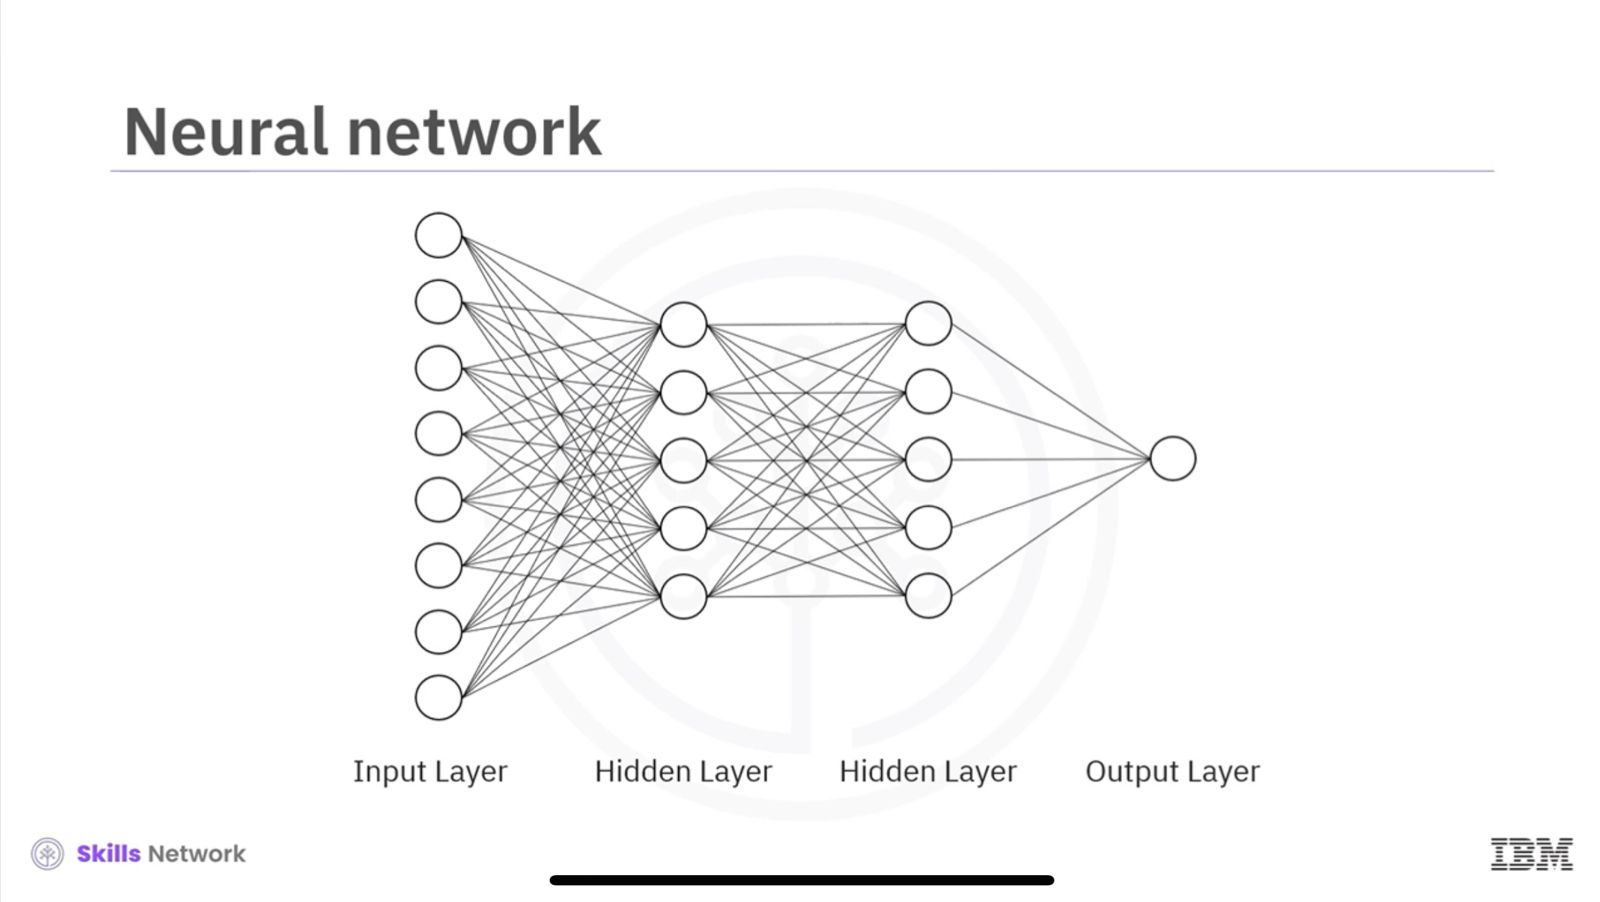

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
# creamos un modelo secuencial
model  = Sequential()
# definimos capa de entrada
model.add(Dense(5, activation= 'relu', input_shape=(n_cols, )))
# capa oculta
model.add(Dense(5, activation= 'relu'))
# capa de salida
model.add(Dense(1))
# compilamos el modelo
model.compile(optimizer='adam', loss='mean_squared_error')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3. "entrenar y evaluar el modelo"
necesitamos ingresar el contenido del dataset a nuestra red DNN para obtener un resultado. posteriormente necesitamos generar una prediciion del modelo

In [ ]:
#  Entrenamiento
history = model.fit(predictors, selector, epochs=50, verbose=1)

# Predicción (con low primeros elementos de los predictores)
predictions = model.predict(predictors)
print(predictions)

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1501.2035   
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1443.0345
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1536.3362 
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1568.7183
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1551.5519 
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1539.5876 
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1526.2861
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1511.1281 
Epoch 9/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1495.3123 
Epoch 10/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1505.4894 
Epoch 11/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1515.0967 
Epoch 12/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1553.7567 
Epoch 13/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1457.8291 
Epoch 14/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1588.7158 
Epoch 15/50
33/33 ━━━━━━━━━━━━

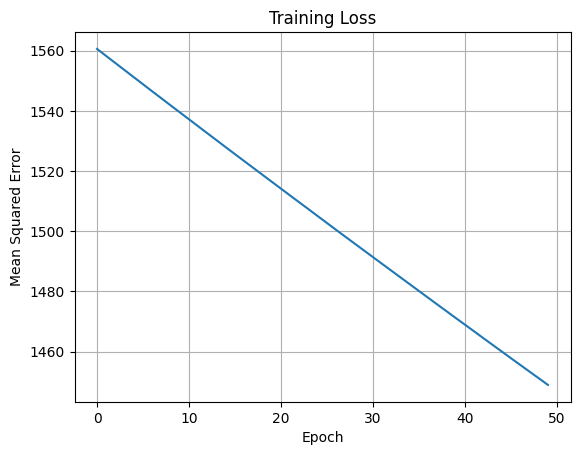

In [ ]:
# Gráfico de perdida
plt.plot(history.history['loss'])
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()

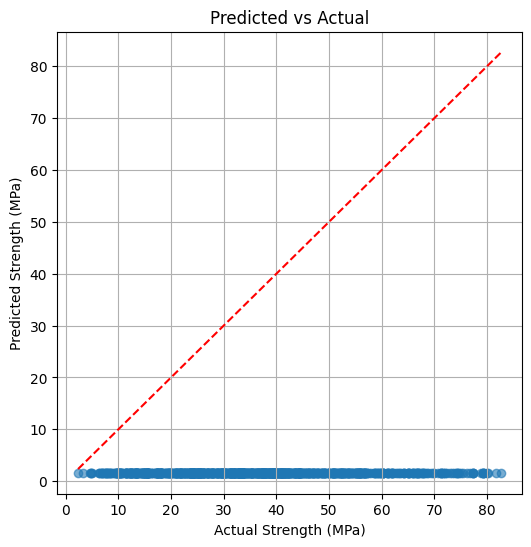

In [ ]:
# Gráfico de dispersión
plt.figure(figsize=(6,6))
plt.scatter(selector, predictions, alpha=0.6)
plt.xlabel('Actual Strength (MPa)')
plt.ylabel('Predicted Strength (MPa)')
plt.title('Predicted vs Actual')
plt.grid(True)
plt.plot([selector.min(), selector.max()], [selector.min(), selector.max()], 'r--')
plt.show()

## **Ejercicio: Mejorar una red densa con Keras**

## Objetivo

Predecir la resistencia del concreto mejorando la red original mediante:
- Más capas ocultas
- Más epochs
- Integración de funciones de activación no lineales (sigmoidea)
## Instrucciones

1. Aumenta la densidad de la capa de entrada de 8 a 10 nodos.
2. Modifica las capas ocultas de la red para que sean 3, con el siguiente numero de nodos respectivamente: 10, 8, 6
3. Cambia la función de activación de la capa de salida por una sigmoidea ("sigmoid")
4. Alimenta la red con un valor de 200 epochs.

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
# creamos un modelo secuencial
model  = Sequential()
# definimos capa de entrada
model.add(Dense(10, activation= 'relu', input_shape=(n_cols, )))
# capa oculta
model.add(Dense(10, activation= 'relu'))
# capa oculta
model.add(Dense(8, activation= 'relu'))
# capa oculta
model.add(Dense(6, activation= 'relu'))
# capa de salida
model.add(Dense(1, activation= 'linear'))
# compilamos el modelo
model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 796.6185
Epoch 2/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 203.5459
Epoch 3/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 163.6687
Epoch 4/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 154.6427
Epoch 5/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 153.4335
Epoch 6/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 148.1958
Epoch 7/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 142.8138
Epoch 8/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 137.2512
Epoch 9/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 132.4309
Epoch 10/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 141.8509
Epoch 11/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 127.3279
Epoch 12/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 124.7365
Epoch 13/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 116.6037
Epoch 14/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 127.6294
Epoch 15/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 

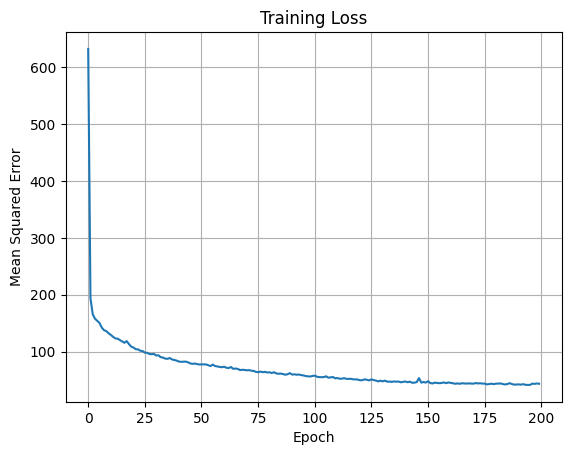

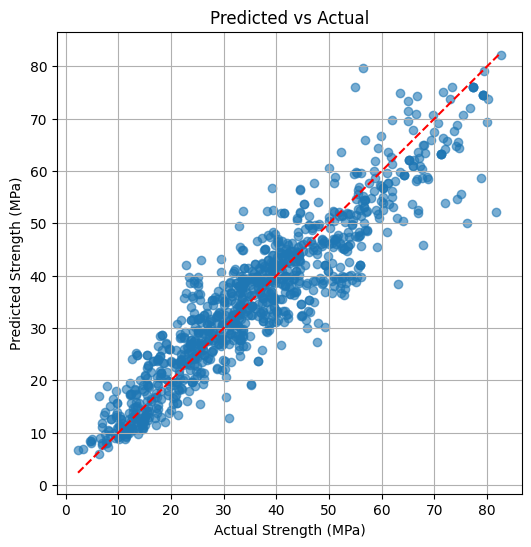

In [ ]:
#  Entrenamiento
history = model.fit(predictors, selector, epochs=200, verbose=1)

# Predicción (con low primeros elementos de los predictores)
predictions = model.predict(predictors)
print(predictions)
# Gráfico de perdida
plt.plot(history.history['loss'])
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()
# Gráfico de dispersión
plt.figure(figsize=(6,6))
plt.scatter(selector, predictions, alpha=0.6)
plt.xlabel('Actual Strength (MPa)')
plt.ylabel('Predicted Strength (MPa)')
plt.title('Predicted vs Actual')
plt.grid(True)
plt.plot([selector.min(), selector.max()], [selector.min(), selector.max()], 'r--')
plt.show()